In [8]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
#coffea output file
f_sig = "../coffea/corrected_sig_2022/corrected_2022.coffea"
#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
print (sig_histo.keys())

dict_keys(['gen_ele_pt', 'gen_ele_eta', 'gen_ele_phi', 'gen_ele_vxy1', 'gen_ele_vxy10', 'gen_ele_vxy100', 'match_ele_gen_pt', 'match_ele_gen_vxy1', 'match_ele_gen_vxy10', 'match_ele_gen_vxy100', 'PFMET', 'PFMET_vs_genMET', 'cutDesc', 'cutflow', 'cutflow_cts', 'cutflow_nevts', 'cutflow_vtx_matched'])


Saved: ./plots//gen_ele_pT.png
edges_den: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 14. 16. 22. 30. 55.]
count_den: [ 83. 108. 194. 157. 121.  78.  59.  32.  33.  19.  25.  11.   4.   7.
   0.   1.]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 14. 16. 30. 55.]
Saved: ./plots/signal_2022/match_ele_gen_pt.png
edges_num: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 14. 16. 22. 30. 55.]
count_num: [ 0.  0.  0.  0.  1.  8. 13.  3. 10.  2.  1.  3.  1.  2.  0.  0.]
bins_x: [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  23.
 42.5]
xerr: [ 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  1.   1.   1.   7.
 12.5]


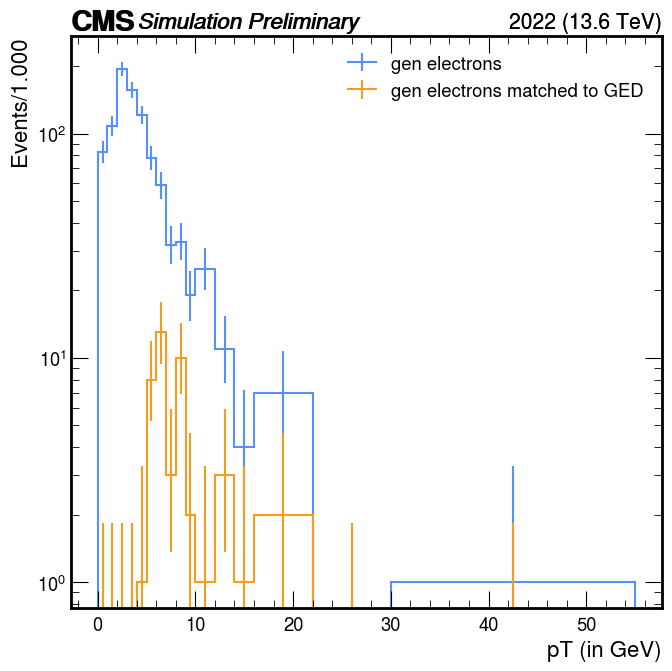

In [10]:
#FOR GED electrons


fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'gen_ele_pT.png'
}
#####
count_den, edges_den = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)
count_den = np.array(count_den)
print ("edges_den:", edges_den)
#print ("len(edges_den):", len(edges_den))
print ("count_den:", count_den)
#print ("len(count_den):", len(count_den))
indices = np.where(count_den == 0)
deno = count_den[count_den != 0]  #IMP


#####
den_edges = np.array(edges_den)
bins_deno = np.delete(den_edges, indices)
print (bins_deno)
###########################################################



m1=10
delta = 0.1
ctau = 10
#fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT (in GeV)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons matched to GED",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'match_ele_gen_pt.png'
}
count_num, edges_num = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='R', passID=1)

#########
count_num = np.array(count_num)
print ("edges_num:", edges_num)
print ("count_num:", count_num)
num = np.delete(count_num, indices)

#########
edges_num = np.array(edges_num)
bins_num = np.delete(edges_num, indices)
#print (bins_num)




#Calculation for the efficiency plot
bins_x = (bins_num[:-1] + bins_num[1:])*(0.5)
print ("bins_x:",bins_x)

xerr = (bins_num[1:] - bins_num[:-1])*(0.5)
print ("xerr:",xerr)







Saved: ./plots/signal_2022/gen_ele_pT_Lmatch.png
edges_den_L: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 14. 16. 22. 30. 55.]
count_den_L: [ 83. 108. 194. 157. 121.  78.  59.  32.  33.  19.  25.  11.   4.   7.
   0.   1.]
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 14. 16. 30. 55.]
Saved: ./plots/signal_2022/match_ele_gen_pt_L.png
edges_num_L: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 12. 14. 16. 22. 30. 55.]
count_num_L: [  0.  38. 163. 133. 109.  61.  41.  21.  20.  17.  23.   8.   3.   5.
   0.   1.]
bins_x_L: [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 11.  13.  15.  23.
 42.5]
xerr_L: [ 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  1.   1.   1.   7.
 12.5]


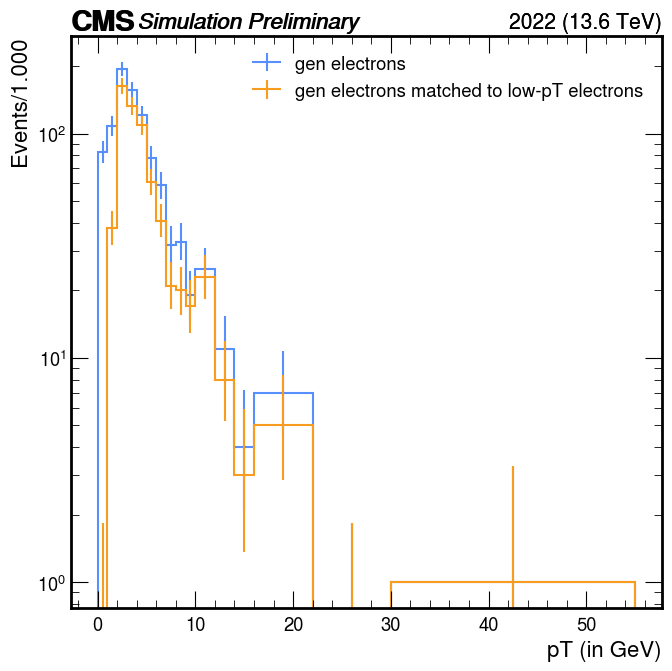

In [11]:
#For low-pT electrons

fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'gen_ele_pT_Lmatch.png'
}
#####
count_den_L, edges_den_L = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)
count_den_L = np.array(count_den_L)
print ("edges_den_L:", edges_den_L)
#print ("len(edges_den):", len(edges_den))
print ("count_den_L:", count_den_L)
#print ("len(count_den):", len(count_den))
indices_L = np.where(count_den_L == 0)
deno_L = count_den_L[count_den_L != 0]  #IMP


#####
den_edges_L = np.array(edges_den_L)
bins_deno_L = np.delete(den_edges_L, indices_L)
print (bins_deno_L)
###########################################################



m1=10
delta = 0.1
ctau = 10
#fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT (in GeV)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen electrons matched to low-pT electrons",    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2022',
    'outName': f'match_ele_gen_pt_L.png'
}
count_num_L, edges_num_L = ptools.plot_signal_1D_match(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)

#########
count_num_L = np.array(count_num_L)
print ("edges_num_L:", edges_num_L)
print ("count_num_L:", count_num_L)
num_L = np.delete(count_num_L, indices_L)

#########
edges_num_L = np.array(edges_num_L)
bins_num_L = np.delete(edges_num_L, indices_L)
#print (bins_num)




#Calculation for the efficiency plot
bins_x_L = (bins_num_L[:-1] + bins_num_L[1:])*(0.5)
print ("bins_x_L:",bins_x_L)

xerr_L = (bins_num_L[1:] - bins_num_L[:-1])*(0.5)
print ("xerr_L:",xerr_L)







In [12]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency_R, unc_eff_R = eff_determine_unc(num, deno)
yerr_R = [unc_eff_R[0], unc_eff_R[1]]

efficiency_L, unc_eff_L = eff_determine_unc(num_L, deno_L)
yerr_L= [unc_eff_L[0], unc_eff_L[1]]

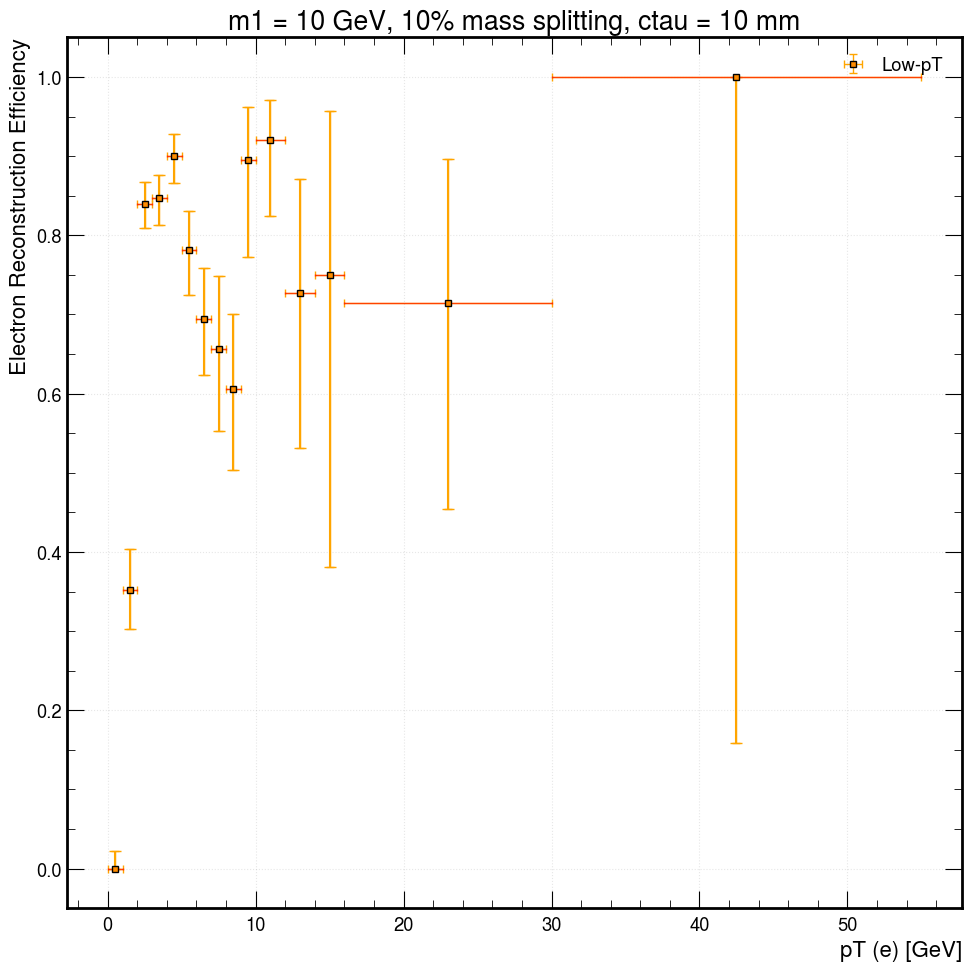

In [13]:
#GED
# plt.errorbar(
#     bins_x, efficiency_R,
#     yerr=yerr_R, xerr=xerr,
#     fmt='o', markersize=6, markerfacecolor='royalblue', markeredgecolor='black',
#     ecolor='gray', elinewidth=1, capsize=3,
#     label='GED'
# )

# # Draw y errors thicker and darker
# plt.errorbar(
#     bins_x, efficiency_R,
#     yerr=yerr_R,
#     fmt='none', ecolor='black', elinewidth=1.5, capsize=4
# )

# # Draw x errors thinner and lighter
# plt.errorbar(
#     bins_x, efficiency_R,
#     xerr=xerr,
#     fmt='none', ecolor='red', elinewidth=1, capsize=1, alpha=0.6
# )


# #Low pT
plt.errorbar(
    bins_x_L, efficiency_L,
    yerr=yerr_L, xerr=xerr_L,
    fmt='s', markersize=5, markerfacecolor='darkorange', markeredgecolor='black',
    ecolor='orange', elinewidth=1, capsize=3,
    label='Low-pT'
)

# Low-pT y errors thicker
plt.errorbar(
    bins_x_L, efficiency_L,
    yerr=yerr_L,
    fmt='none', ecolor='orange', elinewidth=1.5, capsize=4
)

# Low-pT x errors thinner
plt.errorbar(
    bins_x_L, efficiency_L,
    xerr=xerr_L,
    fmt='none', ecolor='red', elinewidth=1, capsize=1, alpha=0.6
)

#plt.plot(bins_x_L, efficiency_L, color='darkorange', linestyle='--', linewidth=1.5)
plt.xlabel("pT (e) [GeV]")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title("m1 = 10 GeV, 10% mass splitting, ctau = 10 mm")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Electron_Reconstruction_Eff_GEDlowpT.png", dpi=300)


In [14]:
plt.errorbar(bins_x, efficiency, yerr , xerr, fmt='o', label = '(m1, dm)=(10,1) GeV')
#plt.step(bins_deno, efficiency, yerr )

# plt.step(bins_deno, efficiency, color='orange')
# plt.errorbar(bins_deno, efficiency, yerr , fmt='o', color='black')


plt.xlabel("pT (in GeV)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title ("m1 = 10 GeV, 10% mass splitting, ctau = 10mm")
plt.legend(["GED"],loc='upper left')
plt.savefig("Electron_Reconstruction_Eff_GED_pT.png")

NameError: name 'efficiency' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(7,7))

m1=10
delta = 0.1
ctau = 10

# Plot settings
plot_dict = {
    'variable': 'gen_ele_pt',
    'cut': 'cut1',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "gen_ele_pt",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'gen_ele_pT.png'
}

count_den, edges_den = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)
# h_den = np.array(h_den)
print ("Count:", count_den)
print ("Edges:", edges_den)

bins_x_den = (edges_den[:-1] + edges_den[1:])*(0.5)
print ("bins_x_den:", bins_x_den)


count_den = np.array(count_den)

indices = np.where(count_den == 0)
print ("indices having element 0:" , indices)

deno = count_den[count_den != 0]  #IMP
print ("Denominator:", deno)  


########################################

edges_den = np.array(bins_x_den)

bins_deno = np.delete(edges_den,indices ) #IMP

print ("bins:",bins_deno)


In [ ]:
m1=10
delta = 0.1
ctau = 10
fig, ax = plt.subplots(figsize=(7,7))

plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut1', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': True, 
    'xlabel': "pT of gen electrons(matched to 'R')",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/',
    'outName': f'match_ele_gen_pt.png'
}
count_num, edges_num = ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict, match_type='L', passID=1)

print ("Count:", count_num)
print ("Edges:", edges_num)

bins_x_num = (edges_num[:-1] + edges_num[1:])*(0.5)
print ("bins_x_num:", bins_x_num)


count_num = np.array(count_num)
num = np.delete(count_num, indices)
print ("num:", num)



edges_num = np.array(bins_x_num)

bins_num = np.delete(edges_num, indices) #IMP

print ("bins:",bins_num)

print(np.array_equal(bins_num, bins_deno))


In [ ]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc

efficiency, unc_eff = eff_determine_unc(num, deno)
print ("Efficiency:",efficiency)
print ("unc-eff:", unc_eff)
yerr = [unc_eff[0], unc_eff[1]]
# print ("yerr:",yerr)

In [ ]:
plt.errorbar(bins_deno, efficiency, yerr , fmt='o', label = '(m1, dm)=(10,1) GeV', color = 'green')
#plt.step(bins_deno, efficiency, yerr )

# plt.step(bins_deno, efficiency, color='orange')
# plt.errorbar(bins_deno, efficiency, yerr , fmt='o', color='black')


plt.xlabel("pT (in GeV)")
plt.ylabel("Electron Reconstruction Efficiency")
plt.title ("ctau = 10mm, 10% mass splitting")
plt.legend(["Low pT"],loc='upper right')
plt.savefig("Electron_Reconstruction_Eff_LowpT_pT.png")
#cross cleaning ntuplizer
#x bins